# Requerimiento 1

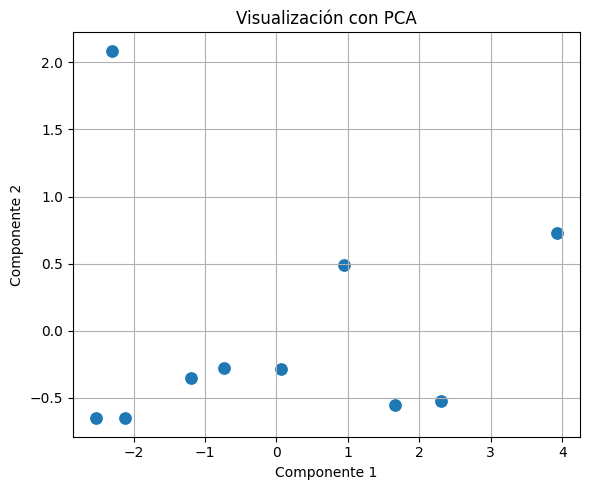

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1. Datos simulados (multivariable) ---
data = {
    'Edad': [21, 35, 27, 40, 29, 50, 33, 45, 31, 22],
    'Horas_estudio': [5, 10, 6, 8, 7, 11, 9, 4, 7, 5],
    'Evaluaciones_aprobadas': [2, 5, 3, 4, 3, 6, 5, 2, 4, 3],
    'Participacion_foro': [3, 9, 4, 7, 5, 10, 8, 2, 6, 3],
    'Tareas_entregadas': [4, 10, 6, 8, 6, 12, 9, 3, 7, 4]
}
df = pd.DataFrame(data)

# --- 2. Escalamiento de datos ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# --- 3. Aplicación de PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- 4. Visualización ---
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], s=100)
plt.title("Visualización con PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.tight_layout()
plt.show()

*Al proyectar las múltiples variables académicas y demográficas en solo dos componentes principales, se logra capturar la mayor varianza posible de los datos en un plano bidimensional, lo cual permite visualizar agrupamientos naturales que revelan patrones ocultos sobre el comportamiento de los estudiantes, separando de manera efectiva aquellos perfiles con alto compromiso (más horas de estudio y tareas entregadas) de aquellos con menor interacción.*

*Propuestas de acción:*
- *Acompañamiento Intensivo: Para aquellos estudiantes ubicados en valores bajos de PC1 (baja participación en foros, pocas horas de estudio y bajo cumplimiento de tareas), activar alertas tempranas automatizadas desde la plataforma. Asignar tutores académicos personalizados y reestructurar su calendario de entregas para mitigar el riesgo de abandono.*
- *Profundización y Excelencia: Para los estudiantes situados en los valores superiores de PC1, ofrecer acceso a rutas aceleradas, material complementario de nivel avanzado y convocatorias para participar como alumnos ayudantes o mentores de sus pares.*
- *Refuerzo Metodológico: Para alumnos que registran alto tiempo de conexión sin lograr buenos resultados pedagógicos, ofrecer talleres de técnicas de estudio y optimización del tiempo para corregir ineficiencias en el aprendizaje.*

# Requerimiento 2

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


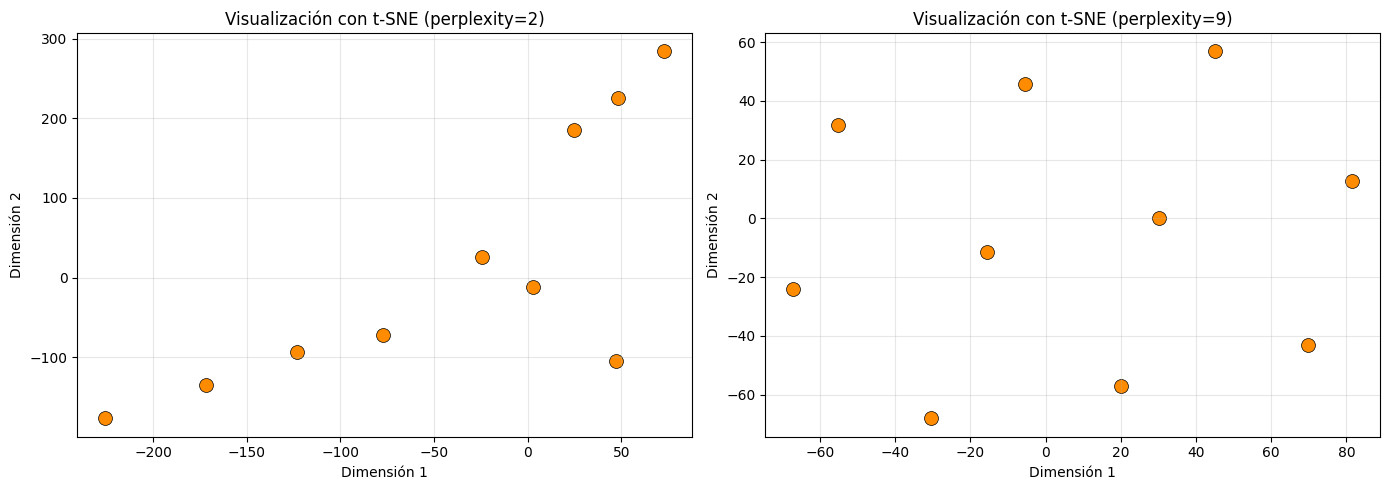

In [8]:
from sklearn.manifold import TSNE

# Se prueba perplexity=2 al ajustarse mejor a datasets ultra pequeños (N=10)
perp = [2,9]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, perp in zip(axes, perp):
  tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=500)
  X_tsne = tsne.fit_transform(X_scaled)

  sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], s=100, color='darkorange', edgecolor='k', linewidth=0.5, ax=ax)
  ax.set_title(f"Visualización con t-SNE (perplexity={perp})")
  ax.set_xlabel("Dimensión 1")
  ax.set_ylabel("Dimensión 2")
  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

*PCA estructura los datos de forma lineal y global, mientras que t-SNE es una técnica no lineal diseñada específicamente para preservar las relaciones locales. t-SNE tiene una alta sensibilidad a la perplejidad, alterando drásticamente cómo se perciben las distancias entre los estudiantes simulados. Por lo tanto, mientras PCA ofrece una visión general más estable de las correlaciones, t-SNE fuerza la separación visual en pequeños clústeres que varían fuertemente según la configuración elegida.*

*Al comparar las proyecciones de t-SNE utilizando perplexity=2 y perplexity=9, se evidencia la alta sensibilidad que tiene esta técnica no lineal frente a sus hiperparámetros.  Con perplexity=2, el modelo prioriza estrictamente la estructura local inmediata, obligando a los datos a disponerse en una trayectoria diagonal que puede generar falsas agrupaciones lineales debido al reducido tamaño de la muestra.  Con perplexity=9, al abarcar prácticamente a la totalidad del conjunto de datos como vecinos ($N=10$), la representación en 2D cambia por completo, desplegando los puntos de manera más uniforme en el plano.  Esta variabilidad confirma que t-SNE no preserva distancias globales ni es determinista como PCA, siendo una herramienta orientada fundamentalmente a la visualización exploratoria localizada más que a la compresión paramétrica o preparación de atributos para producción.*

# Requerimiento 3

| Criterio Técnico / Característica | PCA (Análisis de Componentes Principales) | t-SNE (t-Distributed Stochastic Neighbor Embedding) |
| :--- | :--- | :--- |
| **Tipo de transformación** | Método lineal paramétrico basado en álgebra lineal (matriz de covarianza y autovectores). | Método no lineal estocástico basado en probabilidades de vecindad local y minimización de divergencia KL. |
| **Propósito analítico** | Reducción de dimensionalidad, eliminación de colinealidad y compresión de datos. | Visualización exploratoria localizada de clústeres y patrones ocultos. |
| **Preservación de estructura** | Preserva la **estructura global** (maximiza la varianza acumulada total). | Preserva la **estructura local** (mantiene las relaciones de cercanía entre vecinos inmediatos). |
| **Interpretabilidad** | **Alta:** Permite calcular e interpretar las cargas o pesos (*loadings*) de las variables originales sobre cada componente. | **Baja/Nula:** Los ejes proyectados no representan variables directas ni combinaciones lineales de ellas. |
| **Transformación de nuevos datos** | **Sí (Paramétrico):** Permite proyectar registros futuros utilizando la misma matriz de transformación aprendida. | **No (Transductivo):** No posee una función de mapeo directa; agregar nuevos datos exige reejecutar todo el algoritmo. |
| **Sensibilidad a hiperparámetros** | **Baja:** Determinista (no utiliza semillas aleatorias; solo se define el número de componentes o % de varianza). | **Extremadamente alta:** Muy sensible a la semilla aleatoria (`random_state`), tasa de aprendizaje y la perplejidad (`perplexity`). |
| **Costo computacional** | **Bajo / Eficiente:** Rápido cálculo matemático. | **Moderado a Alto:** Algoritmo iterativo computacionalmente exigente. |
| **Uso en modelos predictivos** | **Recomendado:** Ideal como paso de preprocesamiento antes de alimentar modelos supervisados (regresión/clasificación). | **No recomendado:** Solo debe utilizarse para fines exploratorios y de visualización previa. |
| **Ejemplo de práctico** | Comprimir 100 indicadores financieros/operativos para alimentar un modelo predictivo de riesgo crediticio. | Visualizar en un mapa 2D la distribución no lineal de transacciones para detectar anomalías o transacciones de fraude. |

# Requerimiento 4

*Para preparar e implementar después de un modelo predictivo, lo mejor y más recomendado es PCA, ya que es un modelo lineal determinista que comprime el conjunto de datos conversando la mayor cantidad de información útil, pero además permite interpretar el peso de las variables originales sobre los componentes que se generan. Por otro lado, t-SNE solo está diseñado para visualizar de manera exploratoria y carece de interpretabilidad.*

*PCA permite replicar la misma transformación exacta, consistentemente, a nuevos registros de estudiantes futuros, lo cual es fundamental para cualquier pipeline de aprendizaje automático en producción.*